In [ ]:
# data source: https://www.kaggle.com/datasets/rabieelkharoua/predicting-hiring-decisions-in-recruitment-data/data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.metrics import classification_report, ConfusionMatrixDisplay, f1_score
import warnings
warnings.filterwarnings('ignore')

## STEP 1 — Load & inspect

In [2]:
# ═══════════════════════════════════════════════════════════════════════════════
# STEP 1 — Load & inspect
# ═══════════════════════════════════════════════════════════════════════════════
df = pd.read_csv('recruitment_data.csv')
print("Shape:", df.shape)

Shape: (1500, 11)


In [3]:
df.head()

,Age,Gender,EducationLevel,ExperienceYears,PreviousCompanies,DistanceFromCompany,InterviewScore,SkillScore,PersonalityScore,RecruitmentStrategy,HiringDecision
0,26,1,2,0,3,26.783828,48,78,91,1,1
1,39,1,4,12,3,25.862694,35,68,80,2,1
2,48,0,2,3,2,9.920805,20,67,13,2,0
3,34,1,2,5,2,6.407751,36,27,70,3,0
4,30,0,1,6,1,43.105343,23,52,85,2,0


In [3]:
print("\nDtypes:\n", df.dtypes)
print("\nMissing values:\n", df.isnull().sum())


Dtypes:
 Age                      int64
Gender                   int64
EducationLevel           int64
ExperienceYears          int64
PreviousCompanies        int64
DistanceFromCompany    float64
InterviewScore           int64
SkillScore               int64
PersonalityScore         int64
RecruitmentStrategy      int64
HiringDecision           int64
dtype: object

Missing values:
 Age                    0
Gender                 0
EducationLevel         0
ExperienceYears        0
PreviousCompanies      0
DistanceFromCompany    0
InterviewScore         0
SkillScore             0
PersonalityScore       0
RecruitmentStrategy    0
HiringDecision         0
dtype: int64


In [5]:
print("\nTarget distribution:")
print(df['HiringDecision'].value_counts())
print(df['HiringDecision'].value_counts(normalize=True).round(3) * 100)


Target distribution:
HiringDecision
0    1035
1     465
Name: count, dtype: int64
HiringDecision
0    69.0
1    31.0
Name: proportion, dtype: float64


## STEP 2 — Define features & target

In [23]:
# ═══════════════════════════════════════════════════════════════════════════════
# STEP 2 — Define features & target
# ═══════════════════════════════════════════════════════════════════════════════
# Target: HiringDecision (0 = not hired, 1 = hired)

In [4]:
FEATURES = [
    'Age', 'Gender', 'EducationLevel', 'ExperienceYears',
    'PreviousCompanies', 'DistanceFromCompany',
    'InterviewScore', 'SkillScore', 'PersonalityScore', 
    'RecruitmentStrategy' 
]

X = df[FEATURES].copy()
X.head()

,Age,Gender,EducationLevel,ExperienceYears,PreviousCompanies,DistanceFromCompany,InterviewScore,SkillScore,PersonalityScore,RecruitmentStrategy
0,26,1,2,0,3,26.783828,48,78,91,1
1,39,1,4,12,3,25.862694,35,68,80,2
2,48,0,2,3,2,9.920805,20,67,13,2
3,34,1,2,5,2,6.407751,36,27,70,3
4,30,0,1,6,1,43.105343,23,52,85,2


In [5]:
X['RecruitmentStrategy'].value_counts()

RecruitmentStrategy
2    770
1    445
3    285
Name: count, dtype: int64

In [6]:
pd.crosstab(df['RecruitmentStrategy'], df['HiringDecision'])

HiringDecision,0,1
RecruitmentStrategy,,
1,126,319
2,665,105
3,244,41


In [7]:
pd.crosstab(df['RecruitmentStrategy'], df['HiringDecision'], normalize='columns')

HiringDecision,0,1
RecruitmentStrategy,,
1,0.121739,0.686022
2,0.642512,0.225806
3,0.235749,0.088172


### One-hot Encoding `RecruitmentStrategy`

Recruitment Strategy

Description: Strategy adopted by the hiring team for recruitment.

Categories:
- 1: Aggressive
- 2: Moderate
- 3: Conservative
- 
Data Type: Categorical.

In [4]:
# One-hot encode RecruitmentStrategy
# drop_first=True drops category 1 (Aggressive) as the baseline
# dtype=int keeps it as 0/1 integers, not booleans
X = pd.get_dummies(X, columns=['RecruitmentStrategy'], drop_first=True, dtype=int)

# Verify — you should now see two new columns:
# RecruitmentStrategy_2 (1 = Moderate, 0 = otherwise)
# RecruitmentStrategy_3 (1 = Conservative, 0 = otherwise)
print(X.columns.tolist())
print(X.shape)

['Age', 'Gender', 'EducationLevel', 'ExperienceYears', 'PreviousCompanies', 'DistanceFromCompany', 'InterviewScore', 'SkillScore', 'PersonalityScore', 'RecruitmentStrategy_2', 'RecruitmentStrategy_3']
(1500, 11)


In [10]:
X['RecruitmentStrategy_2'].value_counts()

RecruitmentStrategy_2
1    770
0    730
Name: count, dtype: int64

In [11]:
X['RecruitmentStrategy_3'].value_counts()

RecruitmentStrategy_3
0    1215
1     285
Name: count, dtype: int64

In [5]:
y = df['HiringDecision']   # already 0/1, no encoding needed

# Gender is already correct: Male=0, Female=1 (per Kaggle description)
GENDER_MAP = {0: 'Male', 1: 'Female'}

assert X.select_dtypes('object').empty, "String columns remain!"
assert y.isnull().sum() == 0, "NaNs in target!"
assert set(y.unique()) == {0, 1}, "Unexpected target values!"

In [14]:
X.head()

,Age,Gender,EducationLevel,ExperienceYears,PreviousCompanies,DistanceFromCompany,InterviewScore,SkillScore,PersonalityScore,RecruitmentStrategy_2,RecruitmentStrategy_3
0,26,1,2,0,3,26.783828,48,78,91,0,0
1,39,1,4,12,3,25.862694,35,68,80,1,0
2,48,0,2,3,2,9.920805,20,67,13,1,0
3,34,1,2,5,2,6.407751,36,27,70,0,1
4,30,0,1,6,1,43.105343,23,52,85,1,0


In [26]:
y.head()

0    1
1    1
2    0
3    0
4    0
Name: HiringDecision, dtype: int64

In [15]:
X.shape

(1500, 11)

In [16]:
y.shape

(1500,)

In [18]:
print("\nFeatures:", FEATURES)
print("\nTarget: HiringDecision — 0=Not hired, 1=Hired")


Features: ['Age', 'Gender', 'EducationLevel', 'ExperienceYears', 'PreviousCompanies', 'DistanceFromCompany', 'InterviewScore', 'SkillScore', 'PersonalityScore', 'RecruitmentStrategy']

Target: HiringDecision — 0=Not hired, 1=Hired


## STEP 3 — EDA: class balance

In [6]:
# ═══════════════════════════════════════════════════════════════════════════════
# STEP 3 — EDA: class balance
# ═══════════════════════════════════════════════════════════════════════════════
counts = y.value_counts().sort_index()
pcts   = y.value_counts(normalize=True).sort_index() * 100
ratio  = counts.max() / counts.min()

print("\n=== Class distribution ===")
for label, name in [(0, 'Not hired'), (1, 'Hired')]:
    print(f"  {name:<12} {counts[label]:>5} rows  ({pcts[label]:.1f}%)")
print(f"\nImbalance ratio: {ratio:.2f}x")


=== Class distribution ===
  Not hired     1035 rows  (69.0%)
  Hired          465 rows  (31.0%)

Imbalance ratio: 2.23x


In [20]:
# Decision tree:
if ratio < 1.5:
    print("→ Balanced. Use F1-macro, no resampling needed.")
elif ratio < 3.0:
    print("→ Mild imbalance. Use F1-macro + class_weight='balanced'.")
else:
    print("→ Severe imbalance. Use SMOTE or oversample minority class.")

→ Mild imbalance. Use F1-macro + class_weight='balanced'.


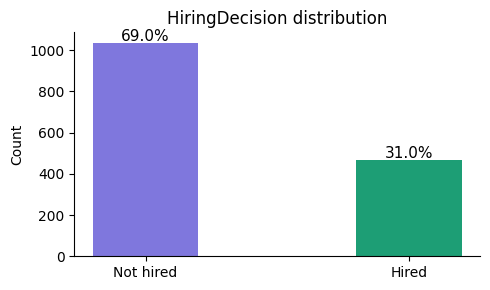

In [21]:
fig, ax = plt.subplots(figsize=(5, 3))
ax.bar(['Not hired', 'Hired'], counts.values,
       color=['#7F77DD', '#1D9E75'], width=0.4)
for i, (v, p) in enumerate(zip(counts.values, pcts.values)):
    ax.text(i, v + 10, f'{p:.1f}%', ha='center', fontsize=11)
ax.set_ylabel('Count')
ax.set_title('HiringDecision distribution')
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()

## STEP 4 — EDA: feature correlations with target

In [22]:
# ═══════════════════════════════════════════════════════════════════════════════
# STEP 4 — EDA: feature correlations with target
# ═══════════════════════════════════════════════════════════════════════════════
correlations = X.corrwith(y).abs().sort_values(ascending=False)
print("\n=== Feature correlations with HiringDecision ===")
print(correlations.round(4))


=== Feature correlations with HiringDecision ===
RecruitmentStrategy_2    0.3856
EducationLevel           0.2367
SkillScore               0.2037
RecruitmentStrategy_3    0.1740
PersonalityScore         0.1692
InterviewScore           0.1461
ExperienceYears          0.1225
PreviousCompanies        0.0440
DistanceFromCompany      0.0168
Gender                   0.0022
Age                      0.0018
dtype: float64


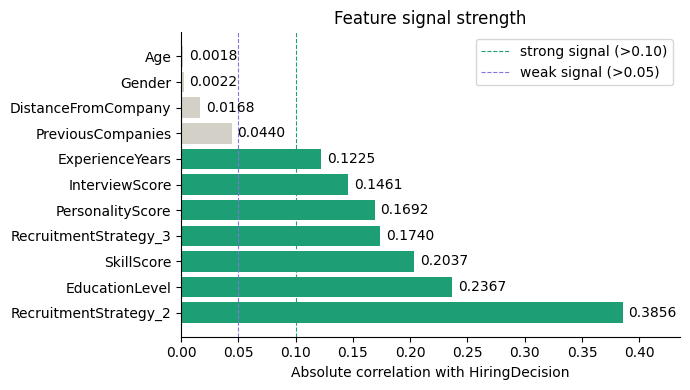

In [23]:
fig, ax = plt.subplots(figsize=(7, 4))

colors = ['#1D9E75' if c > 0.1 else '#7F77DD' if c > 0.05 else '#D3D1C7'
          for c in correlations.values]

bars = ax.barh(correlations.index, correlations.values, color=colors)

#add numbers to the bars
ax.bar_label(bars, labels=[f'{v:.4f}' for v in correlations.values],
             padding=4, fontsize=10)

#draw the vertical reference lines
ax.axvline(x=0.1, color='#1D9E75', linestyle='--',
           linewidth=0.8, label='strong signal (>0.10)')
ax.axvline(x=0.05, color='#7F77DD', linestyle='--',
           linewidth=0.8, label='weak signal (>0.05)')

ax.set_xlabel('Absolute correlation with HiringDecision')
ax.set_title('Feature signal strength')

#set x-axis range
ax.set_xlim(0, correlations.max() + 0.05)

ax.legend(fontsize=10)

#remove top and right borders
ax.spines[['top', 'right']].set_visible(False)

#Automatically adjusts spacing so nothing overlaps
plt.tight_layout()

plt.show()

**What the plot shows**

This is the **absolute correlation** between each raw feature and `HiringDecision`. It answers: **"how much does knowing this feature tell you about whether someone gets hired?"**

# STEP 5 — EDA: InterviewScore vs HiringDecision

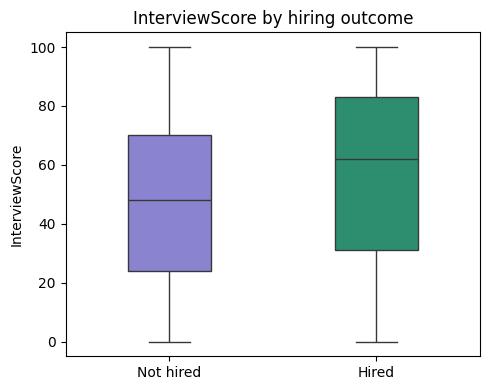

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, ax = plt.subplots(figsize=(5, 4))

df['HiringDecision_label'] = df['HiringDecision'].map(
    {0: 'Not hired', 1: 'Hired'}
)

sns.boxplot(
    data=df, x='HiringDecision_label', y='InterviewScore',
    hue='HiringDecision_label',
    palette={'Not hired': '#7F77DD', 'Hired': '#1D9E75'},
    order=['Not hired', 'Hired'],
    width=0.4, legend=False, ax=ax
)

ax.set_title('InterviewScore by hiring outcome')
ax.set_xlabel('')

plt.tight_layout()
plt.show()

**How to read it:**

- The box spans from Q1 (25th percentile) to Q3 (75th percentile) — this is the interquartile range (IQR), the middle 50% of scores.
- The line inside the box is the median (50th percentile).
- The whiskers extend to the min and max values (or 1.5× IQR in some conventions — seaborn uses the latter by default).

**What the data tells us:**
- the hired group has a higher median (~62 vs ~48)

# STEP 6 — Split (stratified)

In [8]:
# ═══════════════════════════════════════════════════════════════════════════════
# STEP 6 — Split (stratified)
# ═══════════════════════════════════════════════════════════════════════════════
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)
print(f"\nTrain: {X_train.shape[0]} rows | Test: {X_test.shape[0]} rows\n")

for split_name, y_split in [('Train', y_train), ('Test', y_test)]:
    pct_hired = (y_split == 1).mean() * 100
    print(f"  {split_name}: {pct_hired:.1f}% hired")



Train: 1200 rows | Test: 300 rows

  Train: 31.0% hired
  Test: 31.0% hired


# STEP 7 — Feature engineering

- See notebook #2 for the feature

In [9]:
def add_features(df):
    df = df.copy()

    # 1. Weighted composite quality score
    # Hypothesis: hired candidates score high across all three dimensions
    df['composite_score'] = (
        df['InterviewScore']  * 0.4 +
        df['SkillScore']       * 0.4 +
        df['PersonalityScore'] * 0.2
    )
    return df

In [10]:
X_train = add_features(X_train)
X_test  = add_features(X_test)

print(f"\nTotal features after engineering: {X_train.shape[1]}")
assert X_train.isnull().sum().sum() == 0
assert X_test.isnull().sum().sum()  == 0
print("No NaNs introduced.")


Total features after engineering: 12
No NaNs introduced.


In [11]:
X_train.head()

,Age,Gender,EducationLevel,ExperienceYears,PreviousCompanies,DistanceFromCompany,InterviewScore,SkillScore,PersonalityScore,RecruitmentStrategy_2,RecruitmentStrategy_3,composite_score
1253,34,0,3,12,2,10.376361,46,88,77,0,0,69.0
1131,42,1,3,2,2,44.264728,98,75,98,1,0,88.8
734,43,0,1,14,2,28.249114,57,16,44,1,0,38.0
451,48,1,2,0,3,4.446394,35,35,97,0,1,47.4
1266,24,1,2,3,5,45.141158,20,25,4,0,0,18.8


In [12]:
X_train.shape

(1200, 12)

In [13]:
X_test.shape

(300, 12)

# STEP 8 — Correlation check on engineered features

In [14]:
# ═══════════════════════════════════════════════════════════════════════════════
# STEP 8 — Correlation check on engineered features
# ═══════════════════════════════════════════════════════════════════════════════
print("\n=== Engineered feature correlations with HiringDecision ===")
eng_corr = X_train[['composite_score',
                   'RecruitmentStrategy_2', 'RecruitmentStrategy_3']].corrwith(y_train).abs()
print(eng_corr.round(4))



=== Engineered feature correlations with HiringDecision ===
composite_score          0.3076
RecruitmentStrategy_2    0.3829
RecruitmentStrategy_3    0.1696
dtype: float64


# STEP 9 — Scale

In [15]:
# ═══════════════════════════════════════════════════════════════════════════════
# STEP 9 — Scale
# ═══════════════════════════════════════════════════════════════════════════════
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s  = scaler.transform(X_test)

print("\n=== Scaling verification ===")
scale_check = pd.DataFrame({
    'feature': X_train.columns,
    'mean':    X_train_s.mean(axis=0).round(3),
    'std':     X_train_s.std(axis=0).round(3),
})
print(scale_check.to_string(index=False))
assert np.isnan(X_train_s).sum() == 0
assert np.isnan(X_test_s).sum()  == 0
print("All scaling checks passed.")


=== Scaling verification ===
              feature  mean  std
                  Age  -0.0  1.0
               Gender   0.0  1.0
       EducationLevel   0.0  1.0
      ExperienceYears   0.0  1.0
    PreviousCompanies   0.0  1.0
  DistanceFromCompany   0.0  1.0
       InterviewScore   0.0  1.0
           SkillScore   0.0  1.0
     PersonalityScore   0.0  1.0
RecruitmentStrategy_2  -0.0  1.0
RecruitmentStrategy_3   0.0  1.0
      composite_score   0.0  1.0
All scaling checks passed.


# STEP 10 — Model training (5-fold CV)

In [16]:
#defines and configures the models. 
models = {
    'Logistic Regression': Pipeline([
        ('scaler', StandardScaler()),
        ('clf', LogisticRegression(
            max_iter=1000, #It allows up to 1000 adjustment steps to find the best weights.
            class_weight='balanced',
            random_state=42
        ))
    ]),
    'Random Forest': Pipeline([
        ('scaler', StandardScaler()),
        ('clf', RandomForestClassifier(
            n_estimators=300, # builds 300 decision trees and averages their votes. More trees = more stable predictions, but slower.
            class_weight='balanced',
            random_state=42,
            n_jobs=-1 # uses all available CPU cores in parallel to train faster.
        ))
    ]),
    'SVM': Pipeline([
        ('scaler', StandardScaler()),
        ('clf', SVC(
            kernel='rbf', #uses the Radial Basis Function kernel, which maps data into a higher-dimensional space to find a non-linear boundary. Good when classes aren't linearly separable.
            probability=True, #by default SVM only outputs a class label (0 or 1). This enables it to also output probabilities, needed for ROC curves later.
            class_weight='balanced',
            random_state=42
        ))
    ]),
    'Gradient Boosting': Pipeline([
        ('scaler', StandardScaler()),
        ('clf', GradientBoostingClassifier(
            n_estimators=300, # builds 300 trees, but unlike Random Forest these are built sequentially, each one correcting the errors of the previous.
            max_depth=4, #limits how deep each tree can grow. Shallow trees prevent overfitting.
            learning_rate=0.1, #controls how much each new tree contributes. Lower rate = more conservative corrections = less overfitting, but needs more trees to compensate.
            #here, w learning_rate = 0.1 meaning Each tree corrects 10% of the remaining error
            random_state=42
        ))
    ]),
}

In [17]:
# stratified means each fold maintains the same hired/not-hired ratio as the full dataset.
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

- Next, explain the syntax below: 

`cross_val_score(...)` The core function. For each fold it:

- Trains the pipeline on the 4 training folds
- Predicts on the 1 test fold
- Scores the predictions
- Returns all 5 scores as an array

- `scoring`='f1_macro'
    - `F1 score` balances precision and recall. 
    `macro` means it calculates F1 separately for each class (hired, not hired) then averages them equally — so neither class dominates the score.

 - `scores.std()` — standard deviation across folds — tells you how stable the model is. A low std means consistent performance across folds, high std means it's sensitive to which data it sees

 - `scores.mean()` — average F1 across all 5 folds — the main number you compare models by

In [18]:
results     = {}
auc_results = {}  # ← new

print("\n=== 5-fold CV results (F1-macro + ROC-AUC) ===\n")

for name, pipeline in models.items():
    # F1 — already have this
    f1_scores = cross_val_score(
        pipeline, X_train, y_train,
        cv=cv, scoring='f1_macro', n_jobs=-1
    )

    # AUC — add this
    auc_scores = cross_val_score(
        pipeline, X_train, y_train,
        cv=cv, scoring='roc_auc', n_jobs=-1
    )

    results[name]     = f1_scores
    auc_results[name] = auc_scores  # ← new

    print(f"{name:<22} F1={f1_scores.mean():.4f} (±{f1_scores.std():.4f})  "
           f"per-fold={np.round(f1_scores, 3)}     "
          f"AUC={auc_scores.mean():.4f} (±{auc_scores.std():.4f})")


=== 5-fold CV results (F1-macro + ROC-AUC) ===

Logistic Regression    F1=0.8275 (±0.0327)  per-fold=[0.868 0.792 0.807 0.805 0.866]     AUC=0.9090 (±0.0191)
Random Forest          F1=0.8734 (±0.0296)  per-fold=[0.828 0.852 0.891 0.885 0.912]     AUC=0.9240 (±0.0135)
SVM                    F1=0.8531 (±0.0247)  per-fold=[0.847 0.825 0.835 0.863 0.896]     AUC=0.9054 (±0.0183)
Gradient Boosting      F1=0.8950 (±0.0206)  per-fold=[0.908 0.866 0.876 0.907 0.919]     AUC=0.9322 (±0.0194)


| Model                | Mean   | Std Dev | Verdict                              |
|---------------------|--------|--------|--------------------------------------|
| Gradient Boosting   | 0.8950 | 0.0206 | Best mean AND most stable            |
| Random Forest       | 0.8734 | 0.0296 | Good but more variable               |
| SVM                 | 0.8531 | 0.0247 | Decent, consistent                   |
| Logistic Regression | 0.8275 | 0.0327 | Lowest mean AND most variable        |

- **Gradient Boosting (GB):**  
  `[0.908, 0.866, 0.876, 0.907, 0.919]`  
  → Floor is **0.866**, never drops badly

- **Random Forest (RF):**  
  `[0.828, 0.852, 0.891, 0.885, 0.912]`  
  → Floor is **0.828**, more spread

- **Logistic Regression (LR):**  
  `[0.868, 0.792, 0.807, 0.805, 0.866]`  
  → Drops to **0.792** on fold 2, unstable


  GB's worst fold (0.866) is better than RF's best-minus-one fold. That's a genuinely dominant model — not just lucky on the mean.

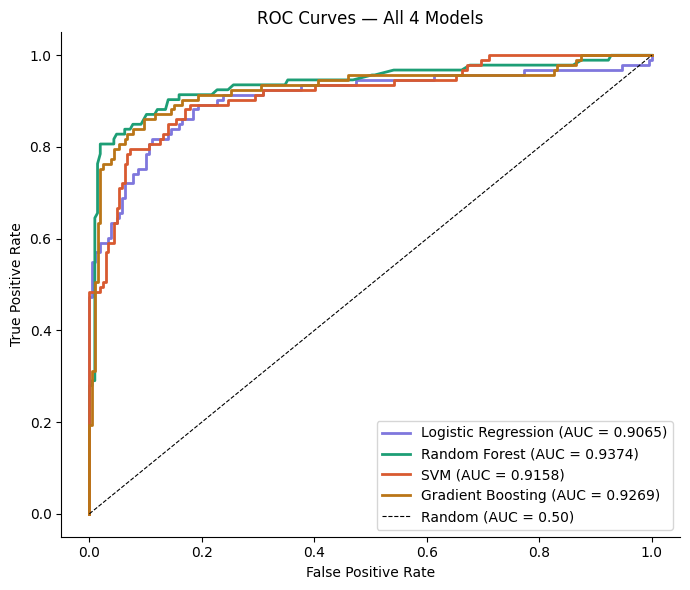

In [19]:
from sklearn.metrics import roc_curve, roc_auc_score

fig, ax = plt.subplots(figsize=(7, 6))

colors = {
    'Logistic Regression': '#7F77DD',
    'Random Forest':       '#1D9E75',
    'SVM':                 '#D85A30',
    'Gradient Boosting':   '#BA7517'
}

for name, pipeline in models.items():
    # Fit on full train, predict proba on test
    pipeline.fit(X_train, y_train)
    y_prob = pipeline.predict_proba(X_test)[:, 1]

    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc_score   = roc_auc_score(y_test, y_prob)

    ax.plot(fpr, tpr,
            label=f'{name} (AUC = {auc_score:.4f})',
            color=colors[name],
            linewidth=2)

# Diagonal baseline — random classifier
ax.plot([0, 1], [0, 1], 'k--', linewidth=0.8, label='Random (AUC = 0.50)')

ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curves — All 4 Models')
ax.legend(loc='lower right', fontsize=10)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()

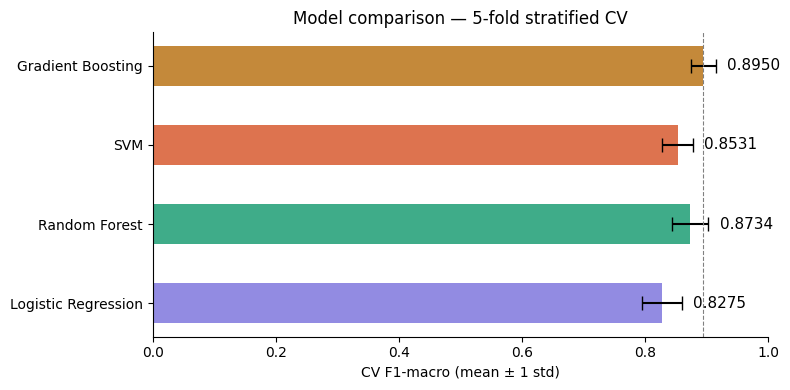

In [20]:
# ── Bar chart ─────────────────────────────────────────────────────────────────
names  = list(results.keys())
means  = [r.mean() for r in results.values()]
stds   = [r.std()  for r in results.values()]
colors = ['#7F77DD', '#1D9E75', '#D85A30', '#BA7517']

fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.barh(names, means, xerr=stds, color=colors,
               alpha=0.85, capsize=5, height=0.5)
ax.bar_label(bars, labels=[f'{m:.4f}' for m in means],
             padding=8, fontsize=11)
ax.set_xlabel('CV F1-macro (mean ± 1 std)')
ax.set_xlim(0, 1)
ax.axvline(x=max(means), color='gray', linestyle='--', linewidth=0.8)
ax.set_title('Model comparison — 5-fold stratified CV')
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()

In [21]:
#GB and RF are very close in their F1-macro. check to see if the difference are stat sign
from scipy import stats

gb_scores = results['Gradient Boosting']
rf_scores = results['Random Forest']

t_stat, p_value = stats.ttest_rel(gb_scores, rf_scores)
print(f"GB vs RF p-value: {p_value:.4f}")
# If p > 0.05, the difference is not statistically significant
# and you should pick RF for its stability

GB vs RF p-value: 0.2407


- The `dashed line` is just the average of all 4 models' mean scores — a reference line showing the overall group average.
   

# STEP 11 - CHECK CONFUSION MATRIX OF 4 MODELS

| Metric    | Meaning                                                                 |
|-----------|-------------------------------------------------------------------------|
| `Precision` | Of everyone the model predicted as `hired`, how many actually were?       |
| `Recall`    | Of everyone actually `hired`, how many did the model catch?               |
| `F1`        | Balance between precision and recall                                   |
| `Support`   | How many actual samples of that class exist in y_test                  |

What to watch for across the 4 models:

- Is `recall` for "Hired" low? → model is missing actual hires (predicting not hired when they should be hired)
- Is `precision` for "Hired" low? → model is over-predicting hires (saying hired when they aren't)
- Are the two classes balanced or is one class much worse than the other?

In [22]:
from sklearn.metrics import classification_report

print("=== Classification Reports — Training CV predictions ===\n")

for name, pipeline in models.items():
    pipeline.fit(X_train, y_train)
    y_pred = pipeline.predict(X_test)
    
    print(f"{'='*45}")
    print(f"  {name}")
    print(f"{'='*45}")
    print(classification_report(
        y_test, y_pred,
        target_names=['Not hired', 'Hired'],
        digits=4
    ))

=== Classification Reports — Training CV predictions ===

  Logistic Regression
              precision    recall  f1-score   support

   Not hired     0.9171    0.8551    0.8850       207
       Hired     0.7196    0.8280    0.7700        93

    accuracy                         0.8467       300
   macro avg     0.8184    0.8415    0.8275       300
weighted avg     0.8559    0.8467    0.8494       300

  Random Forest
              precision    recall  f1-score   support

   Not hired     0.8908    0.9855    0.9358       207
       Hired     0.9577    0.7312    0.8293        93

    accuracy                         0.9067       300
   macro avg     0.9243    0.8583    0.8825       300
weighted avg     0.9116    0.9067    0.9028       300

  SVM
              precision    recall  f1-score   support

   Not hired     0.9073    0.8986    0.9029       207
       Hired     0.7789    0.7957    0.7872        93

    accuracy                         0.8667       300
   macro avg     0.8431   

**Which errors matter more for hiring**

This is the key judgment call your classification report forces you to make:

- `FP (False Positive)` = you interview/hire someone who shouldn't have passed. Costs time and money. You've now onboarded the wrong person, training costs, salary, team disruption, eventual termination. Very expensive and disruptive.
- `FN (False Negative)` = you reject a good candidate. 

This means in a hiring context `precision` for the `Hired` class matters more than `recall`. 

# STEP 12 - Tunning on GB

In [24]:
precision_score

<function sklearn.metrics._classification.precision_score(y_true, y_pred, *, labels=None, pos_label=1, average='binary', sample_weight=None, zero_division='warn')>

In [25]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import make_scorer, precision_score

# ── Scoring: precision on Hired class (label=1) ───────────────────────────────
precision_hired = make_scorer(precision_score, pos_label=1)
precision_hired

make_scorer(precision_score, response_method='predict', pos_label=1)

In [37]:
# ── Parameter search space ────────────────────────────────────────────────────
gb_param_dist = {
    'clf__n_estimators':      [200, 300, 500], # how many trees to build
    'clf__learning_rate':     [0.05, 0.1, 0.2],
    'clf__max_depth':         [3, 4, 5],
    'clf__min_samples_leaf':  [1, 5, 10],
    'clf__min_samples_split': [2, 5, 10],
    'clf__subsample':         [0.7, 0.8, 1.0], # fraction of training rows used per tree
    'clf__max_features':      ['sqrt', 'log2', 0.5], # how many features each tree considers per split
}

At each split point, the tree doesn't look at all 11 features — it randomly considers only a subset:
- sqrt  → considers √11 ≈ 3 features per split
- log2  → considers log₂(11) ≈ 3 features per split  
- 0.5   → considers 50% = 5-6 features per split
  
This forces diversity between trees — if every tree always picks the same dominant feature (like RecruitmentStrategy) at every split, the trees become redundant copies of each other. Limiting features per split forces trees to find different patterns. Best value found: sqrt.

In [29]:

b# ── Pipeline ──────────────────────────────────────────────────────────────────
gb_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', GradientBoostingClassifier(random_state=42))
])

# ── Search ────────────────────────────────────────────────────────────────────
search = RandomizedSearchCV(
    gb_pipeline,
    gb_param_dist,
    n_iter=50,
    cv=cv,                      # your existing StratifiedKFold(5)
    scoring=precision_hired,    # optimize for hired precision
    random_state=42,
    n_jobs=-1,
    verbose=1
)
search.fit(X_train, y_train)

print(f"\nBest CV Precision (Hired): {search.best_score_:.4f}")
print(f"Best params:\n")
for param, value in search.best_params_.items():
    print(f"  {param:<30} {value}")

Fitting 5 folds for each of 50 candidates, totalling 250 fits

Best CV Precision (Hired): 0.9226
Best params:

  clf__subsample                 1.0
  clf__n_estimators              300
  clf__min_samples_split         2
  clf__min_samples_leaf          5
  clf__max_features              sqrt
  clf__max_depth                 5
  clf__learning_rate             0.1


**What 0.9226 means in plain terms**
Out of every 100 candidates the model flags as Hired, approximately 92 of them are genuinely good hires. Only ~8 are false positives — people the model recommended but shouldn't have been hired.

## Final eval on tuned GB

In [38]:
from sklearn.metrics import (
    classification_report,
    ConfusionMatrixDisplay,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve
)

best_model = search.best_estimator_
y_pred     = best_model.predict(X_test)
y_prob     = best_model.predict_proba(X_test)[:, 1]


In [40]:
# ── Classification report ─────────────────────────────────────────────────────
print("=== Final Test Set Evaluation — Tuned Gradient Boosting ===\n")
print(classification_report(
    y_test, y_pred,
    target_names=['Not hired', 'Hired'],
    digits=4
))

=== Final Test Set Evaluation — Tuned Gradient Boosting ===

              precision    recall  f1-score   support

   Not hired     0.9062    0.9807    0.9420       207
       Hired     0.9474    0.7742    0.8521        93

    accuracy                         0.9167       300
   macro avg     0.9268    0.8774    0.8970       300
weighted avg     0.9190    0.9167    0.9141       300



- Not Hired (207 actual non-hires)
    - `Precision` 0.9062 → when model says "not hired", it's right 90.6% of the time
    - `Recall`    0.9807 → model correctly identifies 98% of actual non-hires
    - `F1`        0.9420 → strong overall performance on this class

The model is very good at identifying people who shouldn't be hired. It almost never misses a non-hire (recall 0.98).

- Hired (93 actual hires)
    - `Precision` 0.9474 → when model says "hired", it's right 94.7% of the time ✅
    - `Recall`    0.7742 → model only catches 77.4% of actual hires ⚠️
    - `F1`        0.8521
      
This is the precision-recall tradeoff you chose. By optimizing for precision, the model became conservative — it only recommends someone when it's very confident. But as a result it misses about 23% of genuinely good candidates.


In [41]:
# ── Key metrics summary ───────────────────────────────────────────────────────
print("=== Key Metrics ===")
print(f"Precision (Hired) : {precision_score(y_test, y_pred, pos_label=1):.4f}  ← primary goal")
print(f"Recall    (Hired) : {recall_score(y_test, y_pred, pos_label=1):.4f}")
print(f"F1-macro          : {f1_score(y_test, y_pred, average='macro'):.4f}")
print(f"ROC-AUC           : {roc_auc_score(y_test, y_prob):.4f}")

=== Key Metrics ===
Precision (Hired) : 0.9474  ← primary goal
Recall    (Hired) : 0.7742
F1-macro          : 0.8970
ROC-AUC           : 0.9331


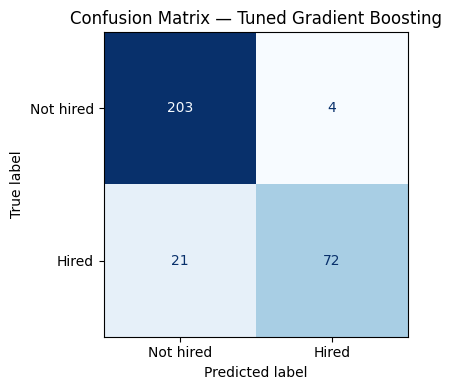

In [42]:
# ── Confusion matrix ──────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred,
    display_labels=['Not hired', 'Hired'],
    cmap='Blues',
    colorbar=False,
    ax=ax
)
ax.set_title('Confusion Matrix — Tuned Gradient Boosting')
plt.tight_layout()
plt.show()

The core tradeoff visualised
- FP = 4   → only 4 wrong hire recommendations   ✅ precision goal achieved
- FN = 21  → 21 good candidates incorrectly rejected ⚠️ cost of being conservative
  
The model is essentially saying: "I'd rather pass on a good candidate than risk recommending a bad one." That's exactly the behaviour you asked for when you chose to optimise for hired precision.

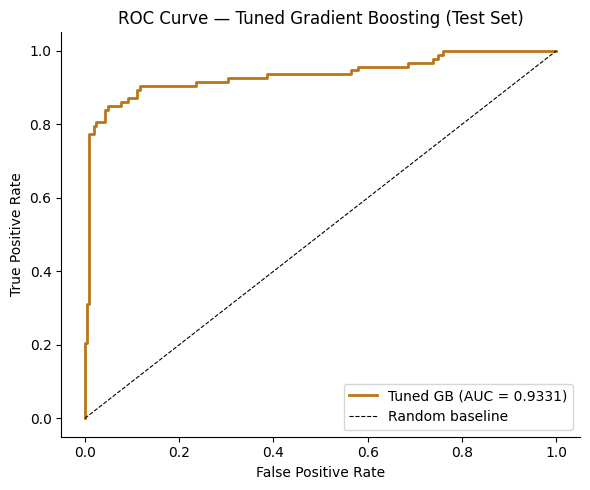

In [43]:
# ── ROC curve ─────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(6, 5))
fpr, tpr, _ = roc_curve(y_test, y_prob)

ax.plot(fpr, tpr, color='#BA7517', linewidth=2,
        label=f'Tuned GB (AUC = {roc_auc_score(y_test, y_prob):.4f})')
ax.plot([0, 1], [0, 1], 'k--', linewidth=0.8, label='Random baseline')

ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curve — Tuned Gradient Boosting (Test Set)')
ax.legend(loc='lower right')
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()

# Step 14 — Compare tuned GB vs untuned GB

In [44]:
# ── Quick before/after comparison ─────────────────────────────────────────────
untuned_gb = models['Gradient Boosting']   # already fitted in Step 11
untuned_pred = untuned_gb.predict(X_test)
untuned_prob = untuned_gb.predict_proba(X_test)[:, 1]

print("=== Tuning Impact ===\n")
print(f"{'Metric':<25} {'Untuned':>10} {'Tuned':>10} {'Change':>10}")
print("-" * 55)

metrics = {
    'Precision (Hired)': (
        precision_score(y_test, untuned_pred, pos_label=1),
        precision_score(y_test, y_pred,       pos_label=1)
    ),
    'Recall (Hired)': (
        recall_score(y_test, untuned_pred, pos_label=1),
        recall_score(y_test, y_pred,       pos_label=1)
    ),
    'F1-macro': (
        f1_score(y_test, untuned_pred, average='macro'),
        f1_score(y_test, y_pred,       average='macro')
    ),
    'ROC-AUC': (
        roc_auc_score(y_test, untuned_prob),
        roc_auc_score(y_test, y_prob)
    ),
}

for metric, (before, after) in metrics.items():
    change = after - before
    arrow  = '↑' if change > 0 else '↓'
    print(f"{metric:<25} {before:>10.4f} {after:>10.4f} {arrow} {abs(change):.4f}")

=== Tuning Impact ===

Metric                       Untuned      Tuned     Change
-------------------------------------------------------
Precision (Hired)             0.8987     0.9474 ↑ 0.0486
Recall (Hired)                0.7634     0.7742 ↑ 0.0108
F1-macro                      0.8777     0.8970 ↑ 0.0193
ROC-AUC                       0.9269     0.9331 ↑ 0.0063


# Step 15 — SHAP on Tuned Gradient Boosting

In [47]:
import shap
shap.initjs()

# Extract components from tuned pipeline
gb_model      = best_model.named_steps['clf']
X_test_scaled = best_model.named_steps['scaler'].transform(X_test)
X_train_scaled = best_model.named_steps['scaler'].transform(X_train)
feature_names = X_test.columns.tolist()

# TreeExplainer — exact, fast for GB
explainer   = shap.TreeExplainer(gb_model)
shap_values = explainer.shap_values(X_test_scaled)

print("SHAP values shape:", shap_values.shape)  # should be (300, 11)
print("Features:", feature_names)

SHAP values shape: (300, 12)
Features: ['Age', 'Gender', 'EducationLevel', 'ExperienceYears', 'PreviousCompanies', 'DistanceFromCompany', 'InterviewScore', 'SkillScore', 'PersonalityScore', 'RecruitmentStrategy_2', 'RecruitmentStrategy_3', 'composite_score']


## Plot 1 — Bar (global feature importance ranking)

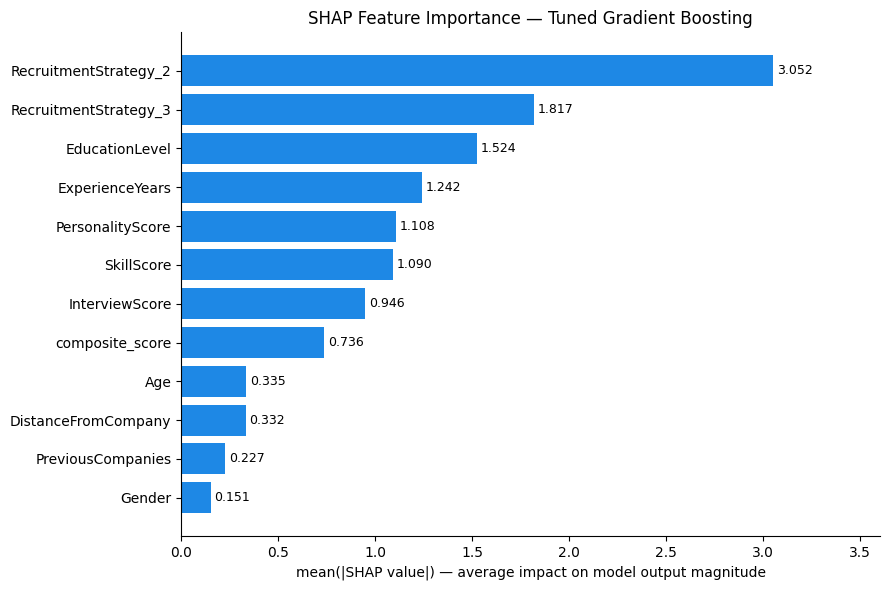

In [54]:
import numpy as np

# Compute mean absolute SHAP values manually so we can annotate
mean_shap = np.abs(shap_values).mean(axis=0)
sorted_idx = np.argsort(mean_shap)  # ascending for horizontal bar

sorted_features = [feature_names[i] for i in sorted_idx]
sorted_values   = mean_shap[sorted_idx]

fig, ax = plt.subplots(figsize=(9, 6))

bars = ax.barh(sorted_features, sorted_values, color='#1E88E5')

# Add value labels at the end of each bar
for bar, val in zip(bars, sorted_values):
    ax.text(
        val + 0.02,                    # slight offset from bar tip
        bar.get_y() + bar.get_height() / 2,
        f'{val:.3f}',                  # 3 decimal places
        va='center',
        ha='left',
        fontsize=9
    )

# Extend x axis slightly so labels don't get clipped
ax.set_xlim(0, sorted_values.max() * 1.18)

ax.set_xlabel('mean(|SHAP value|) — average impact on model output magnitude')
ax.set_title('SHAP Feature Importance — Tuned Gradient Boosting')
ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.show()

**What the X axis means**

`mean(|SHAP value|)` = on average, how much does this feature move the model's prediction away from the baseline, across all 300 test candidates. Bigger bar = more influential feature.

Think of the baseline as the model's default answer if it knew nothing about a candidate. Each feature then pushes that answer up or down by some amount. The bar shows the average size of that push, ignoring direction.

Tier 1 — Process features (recruiting strategy):
- RecruitmentStrategy_2    3.052  ← dominant by huge margin
- RecruitmentStrategy_3    1.817
Combined impact:         4.869
+ --> 4.869 / 12.560 = 38.8%

Tier 2 — Candidate quality features:
- EducationLevel           1.524
- ExperienceYears          1.242
- PersonalityScore         1.108
- SkillScore               1.090
- InterviewScore           0.946
- composite_score          0.736
Combined impact:         6.646
+ --> 6.646 / 12.560 = 52.9% 

Tier 3 — Near-noise features:
- Age                      0.335
- DistanceFromCompany      0.332
- PreviousCompanies        0.227
- Gender                   0.151
Combined impact:         1.045
+ --> 1.045 / 12.560 =  8.3%

**Key observations**
1. `RecruitmentStrategy_2` at 3.052 is abnormally dominant
The gap between first (3.052) and third place (1.524) is larger than the gap between third and last (1.524 vs 0.151). One feature is pulling twice as hard as the next closest candidate quality signal.
In plain terms: whether someone came through a `Moderate` recruiting strategy matters more to the model than their education, experience, and all three interview scores combined.

    2. The three interview scores are surprisingly equal
- PersonalityScore    1.108
- SkillScore          1.090   ← only 0.018 apart
- InterviewScore      0.946
Your `composite_score` weighted them as 0.4 / 0.4 / 0.2, but the model treats all three as nearly equal contributors. PersonalityScore actually edges out SkillScore despite getting the lowest weight in your formula — a signal that your weighting assumptions may be worth revisiting.

    3. `composite_score` (0.736) ranks below all its components
PersonalityScore    1.108  ↑
SkillScore          1.090  ↑
InterviewScore      0.946  ↑
composite_score     0.736  ← lower than all three
This confirms it's partially redundant. The model already extracts the signal from the three raw scores directly, so the composite adds diminishing value on top of them. You could consider dropping it in a future iteration.

4. Gender at 0.151 is the lowest feature — good news
The model is barely using gender to make decisions. From a fairness standpoint this is the result you want to see. It doesn't mean zero gender influence, but 0.151 vs 3.052 for strategy means gender is 20x less influential than the recruiting process.

**The headline finding for your conclusion**
- ~39% of predictive power → recruiting process (strategy)
- ~53% of predictive power → candidate quality (education, experience, scores)
- ~8% of predictive power → demographic noise (age, distance, gender)

## Plot 2 — Beeswarm (direction + distribution)

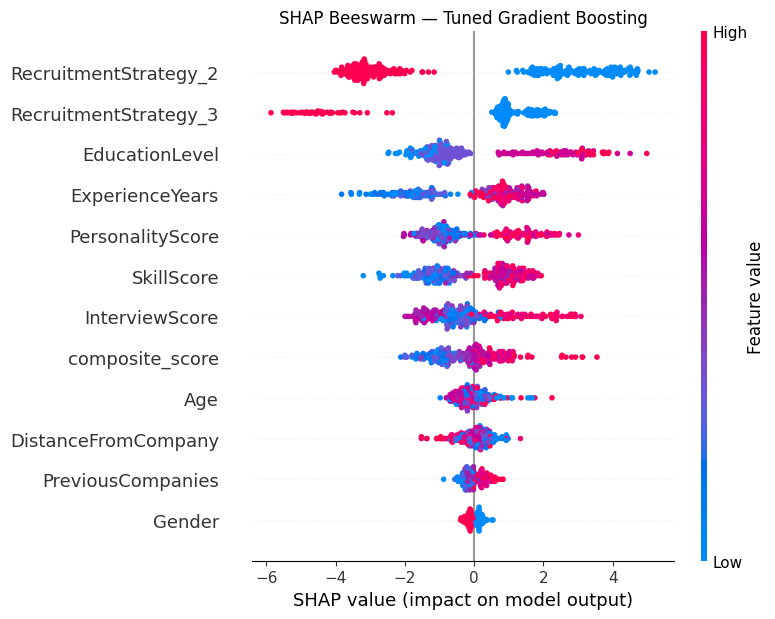

In [50]:
plt.figure(figsize=(8, 6))
shap.summary_plot(
    shap_values,
    X_test_scaled,
    feature_names=feature_names,
    plot_type='dot',
    show=False
)
plt.title('SHAP Beeswarm — Tuned Gradient Boosting')
plt.tight_layout()
plt.show()

Dot position (X axis) → direction of impact
  - left  (negative) = pushes toward NOT hired
  - right (positive) = pushes toward HIRED

Dot color → the feature value for that candidate
  - RED  = high feature value
  - BLUE = low feature value

Dot density → how many candidates cluster at that impact level

`RecruitmentStrategy_2` (Moderate)
- Red dots  → left side  (negative SHAP, ~-4 to -2)
- Blue dots → right side (positive SHAP, ~+2 to +5)

Remember this is a binary OHE column: 1 = Moderate, 0 = not Moderate. So:

- Red = value is 1 (IS Moderate) → pushes strongly toward not hired
- Blue = value is 0 (NOT Moderate) → pushes strongly toward hired

This means `Moderate` strategy candidates are less likely to be hired. `Aggressive` (the baseline, value=0) is the stronger hiring strategy.

    `RecruitmentStrategy_3` (Conservative)
- Red dots  → left side  (negative SHAP, ~-5 to -3)
- Blue dots → right side (positive SHAP, ~+1 to +2)

Same pattern but stronger on the left:

- Red = value is 1 (IS Conservative) → pushes very strongly toward not hired
- Blue = value is 0 (NOT Conservative) → mild push toward hired

`Conservative` strategy is the worst recruiting channel for getting hired. The leftward red cluster at -5 is the most extreme negative signal in the entire chart.


**The one surprising finding**
`RecruitmentStrategy_2` red dots are on the LEFT — meaning `Moderate` strategy (value=1) hurts hiring chances. Intuitively you might expect `Moderate` to be neutral compared to `Aggressive`. But the model says `Aggressive` (the baseline, encoded as 0 in both columns) is actually the most hire-positive strategy, Moderate is negative, and Conservative is strongly negative.

The hierarchy the model learned:
- Aggressive  →  most hires      ✅
- Moderate    →  fewer hires     ⚠️
- Conservative → fewest hires    ❌

This is exactly why OHE was the right choice — if you'd left it as ordinal 1/2/3, the model could never have captured that Aggressive (1) is distinctly better than both others, not just "lower" on a scale.

## Plot 3 — Dependence plots (top 3 features)

<Figure size 700x400 with 0 Axes>

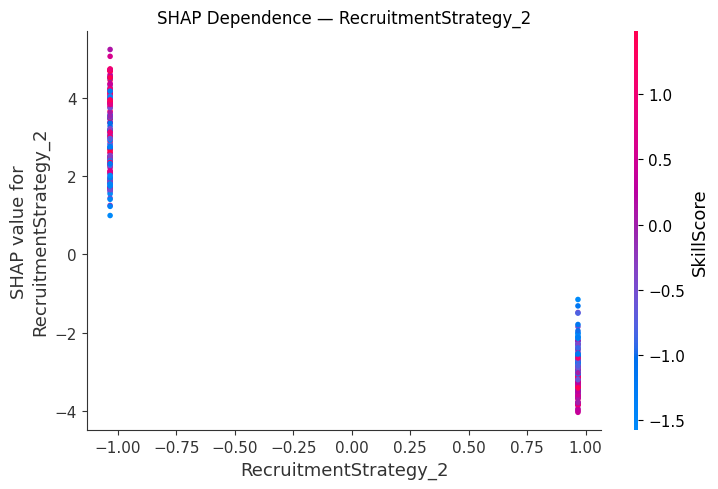

<Figure size 700x400 with 0 Axes>

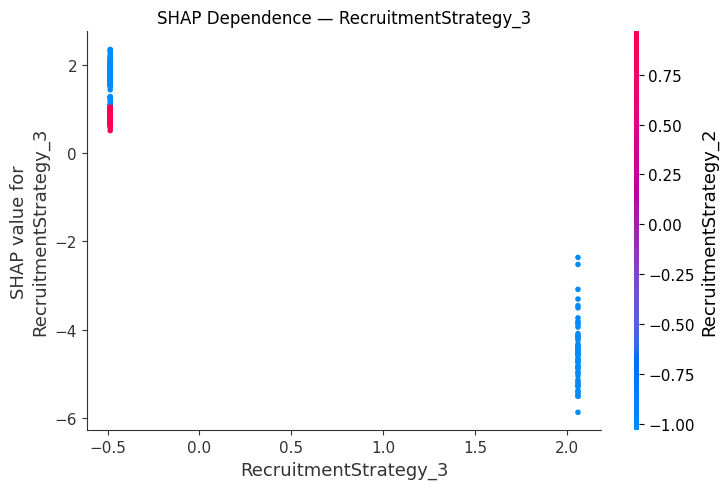

<Figure size 700x400 with 0 Axes>

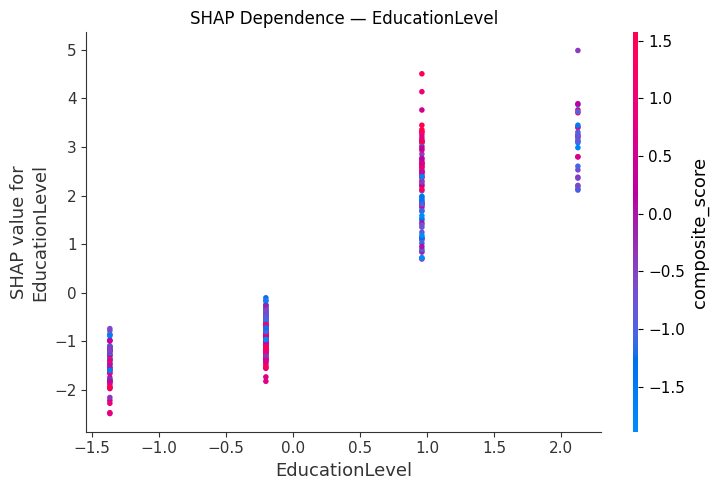

In [52]:
# Run for your 3 most important features
# Adjust this list based on what Plot 1 ranking shows
top_features = [
    'RecruitmentStrategy_2',
    'RecruitmentStrategy_3',
    'EducationLevel'
]

for feature in top_features:
    feat_idx = feature_names.index(feature)
    plt.figure(figsize=(7, 4))
    shap.dependence_plot(
        feat_idx,
        shap_values,
        X_test_scaled,
        feature_names=feature_names,
        show=False
    )
    plt.title(f'SHAP Dependence — {feature}')
    plt.tight_layout()
    plt.show()

## Plot 4 — Waterfall (explain one prediction)

In [58]:
# Explain a specific candidate — try a few interesting cases

# Case A: correctly hired (TP)
tp_indices = [i for i in range(len(y_test))
              if y_test.iloc[i] == 1 and y_pred[i] == 1]

# Case B: incorrectly rejected (FN) — a good candidate the model missed
fn_indices = [i for i in range(len(y_test))
              if y_test.iloc[i] == 1 and y_pred[i] == 0]


In [59]:
# Check what expected_value looks like first
print(type(explainer.expected_value))
print(explainer.expected_value)

<class 'numpy.ndarray'>
[-2.7640734]


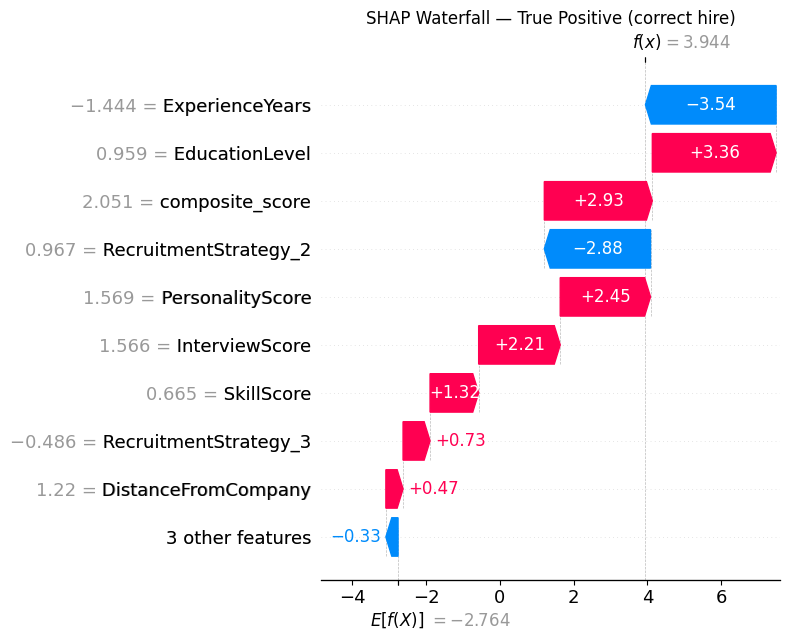


Candidate details (True Positive (correct hire)):
 Age  Gender  EducationLevel  ExperienceYears  PreviousCompanies  DistanceFromCompany  InterviewScore  SkillScore  PersonalityScore  RecruitmentStrategy_2  RecruitmentStrategy_3  composite_score
27.0     1.0             3.0              1.0                2.0            43.547595            96.0        71.0              96.0                    1.0                    0.0             86.0
Predicted: Hired | Actual: Hired

------------------------------------------------------------


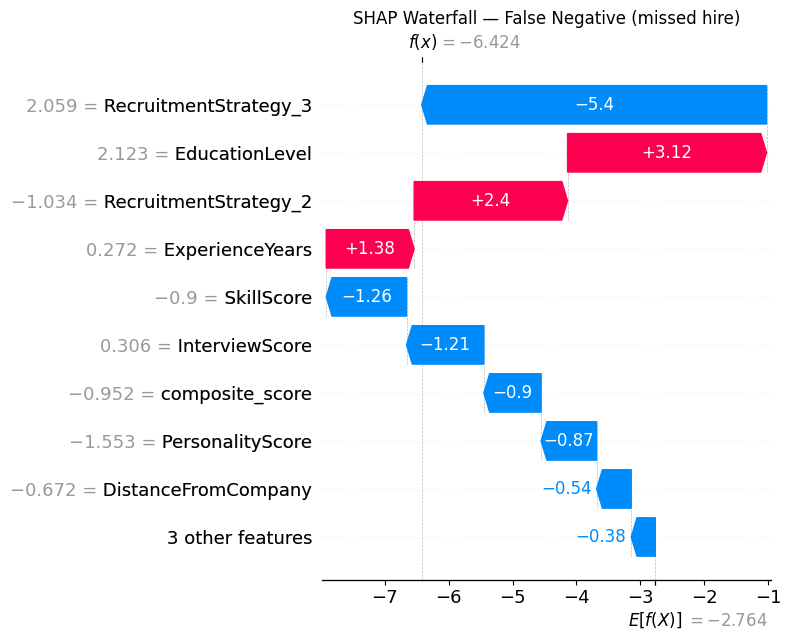


Candidate details (False Negative (missed hire)):
 Age  Gender  EducationLevel  ExperienceYears  PreviousCompanies  DistanceFromCompany  InterviewScore  SkillScore  PersonalityScore  RecruitmentStrategy_2  RecruitmentStrategy_3  composite_score
45.0     0.0             4.0              9.0                2.0            15.962421            60.0        25.0               4.0                    0.0                    1.0             34.8
Predicted: Not hired | Actual: Hired

------------------------------------------------------------


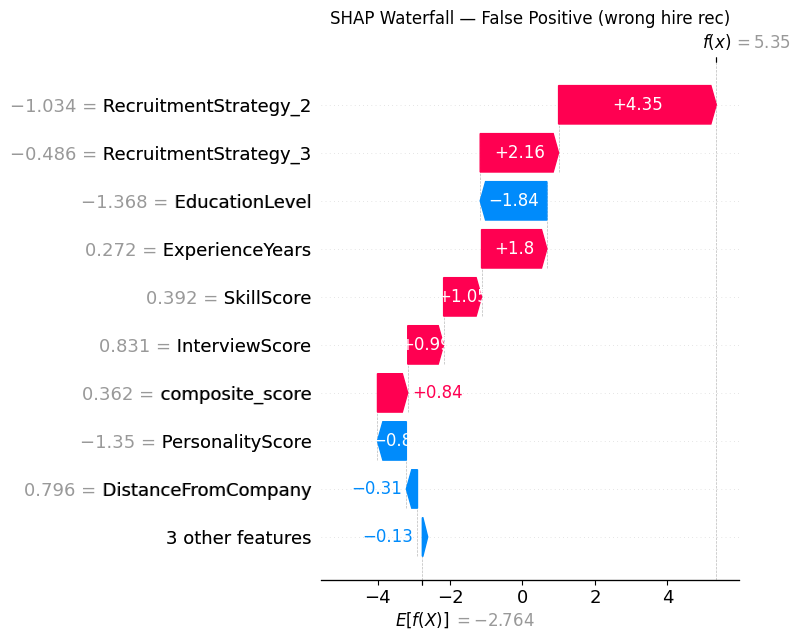


Candidate details (False Positive (wrong hire rec)):
 Age  Gender  EducationLevel  ExperienceYears  PreviousCompanies  DistanceFromCompany  InterviewScore  SkillScore  PersonalityScore  RecruitmentStrategy_2  RecruitmentStrategy_3  composite_score
32.0     0.0             1.0              9.0                1.0            37.378152            75.0        63.0              10.0                    0.0                    0.0             57.2
Predicted: Hired | Actual: Not hired

------------------------------------------------------------


In [61]:
# Single element array — extract index 0
base_val = float(explainer.expected_value[0])

for label, indices in [('True Positive (correct hire)', tp_indices),
                        ('False Negative (missed hire)', fn_indices),
                        ('False Positive (wrong hire rec)', fp_indices)]:

    if not indices:
        print(f"No {label} cases found")
        continue

    idx = indices[0]

    explanation = shap.Explanation(
        values        = shap_values[idx],
        base_values   = base_val,
        data          = X_test_scaled[idx],
        feature_names = feature_names
    )

    shap.plots.waterfall(explanation, show=False)
    plt.title(f'SHAP Waterfall — {label}')
    plt.tight_layout()
    plt.show()

    print(f"\nCandidate details ({label}):")
    print(X_test.iloc[idx].to_frame().T.to_string(index=False))
    print(f"Predicted: {'Hired' if y_pred[idx]==1 else 'Not hired'} | "
          f"Actual: {'Hired' if y_test.iloc[idx]==1 else 'Not hired'}\n")
    print("-" * 60)

In [46]:
from sklearn.model_selection import RandomizedSearchCV

param_dist = {
    'clf__n_estimators':      [100, 200, 300, 500],
    'clf__max_depth':         [None, 5, 10, 15, 20],
    'clf__min_samples_split': [2, 5, 10],
    'clf__min_samples_leaf':  [1, 2, 4],
    'clf__max_features':      ['sqrt', 'log2', 0.5],
    'clf__class_weight':      ['balanced', 'balanced_subsample'],
}

rf_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', RandomForestClassifier(random_state=42, n_jobs=-1))
])

search = RandomizedSearchCV(
    rf_pipeline,
    param_dist,
    n_iter=50,
    cv=cv,
    scoring='f1_macro',
    random_state=42,
    n_jobs=-1,
    verbose=1
)
search.fit(X_train, y_train)

print(f"\nBest CV F1-macro: {search.best_score_:.4f}")
print(f"Best params: {search.best_params_}")

Fitting 5 folds for each of 50 candidates, totalling 250 fits

Best CV F1-macro: 0.6742
Best params: {'clf__n_estimators': 200, 'clf__min_samples_split': 5, 'clf__min_samples_leaf': 2, 'clf__max_features': 'log2', 'clf__max_depth': 20, 'clf__class_weight': 'balanced'}


=== Test set evaluation ===

              precision    recall  f1-score   support

   Not hired       0.76      0.90      0.83       207
       Hired       0.64      0.38      0.47        93

    accuracy                           0.74       300
   macro avg       0.70      0.64      0.65       300
weighted avg       0.72      0.74      0.72       300

F1-macro:  0.6502
ROC-AUC:   0.7325


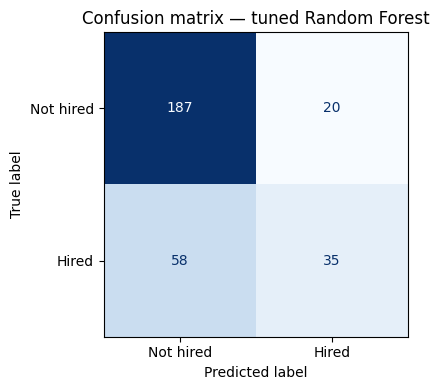

In [47]:
from sklearn.metrics import (
    classification_report,
    ConfusionMatrixDisplay,
    f1_score,
    roc_auc_score
)

# Best model from tuning
best_model = search.best_estimator_
y_pred = best_model.predict(X_test)
y_prob = best_model.predict_proba(X_test)[:, 1]

# ── Classification report ─────────────────────────────────────────────────────
print("=== Test set evaluation ===\n")
print(classification_report(
    y_test, y_pred,
    target_names=['Not hired', 'Hired']
))
print(f"F1-macro:  {f1_score(y_test, y_pred, average='macro'):.4f}")
print(f"ROC-AUC:   {roc_auc_score(y_test, y_prob):.4f}")

# ── Confusion matrix ──────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred,
    display_labels=['Not hired', 'Hired'],
    cmap='Blues',
    colorbar=False,
    ax=ax
)
ax.set_title('Confusion matrix — tuned Random Forest')
plt.tight_layout()
plt.show()

# STEP 16 - Prep for deployment

In [62]:
import joblib
joblib.dump(best_model, 'tuned_gb_hiring_model.pkl')
print("Model saved.")

Model saved.
